# Обучение дерева на сортах вина — `wine_train.ipynb`

Это ноутбук **обучающего этапа** недельного проекта. Здесь мы загружаем датасет, проводим EDA, обучаем `DecisionTreeClassifier`, подбираем регуляризацию и сохраняем готовую модель в `models/wine_model.pkl`. На этапе сервиса (Шаг 2 проекта и далее) этот pickle загружается в FastAPI и отдаётся через браузерную форму.

## Бизнес-сценарий

Винодельня в одном итальянском регионе делает вино из трёх сортов винограда: `class_0`, `class_1` и `class_2`. Перед розливом в каждой партии лаборатория измеряет 13 ключевых химических показателей: содержание алкоголя, фенолов, флавоноидов, цветовую интенсивность.

**Реалистичная сложность.** Лаборант, который размечает партии в логах, иногда ошибается. Не часто, но и не редко — около 10-15% случаев. Это значит, что **обучающая выборка содержит шум в разметке** (label noise). Тестовую выборку мы получили от независимого аудитора, и она чистая. Главный вопрос недели: можно ли по шумной разметке обучить надёжную модель? Регуляризация — основной инструмент, который защищает дерево от подгонки под ошибочные точки в train.

## Как читать этот ноутбук

Ноутбук **пошаговый**. Каждый этап разбит на маленькие ячейки: одна делает что-то одно (загружает данные, рисует график, считает метрику). После каждого блока есть markdown-комментарий, что мы только что увидели и что собираемся сделать дальше. Идите сверху вниз и не пропускайте markdown — без него код выглядит как набор магических заклинаний.

## Этапы

1. **EDA** — что в данных: распределения, баланс классов, корреляции
2. **Split + label noise** — делим train/test, в train кладём шум разметки 15%
3. **Базовая модель** — обучим дерево без регуляризации и увидим переобучение
4. **Регуляризация** — подберём `max_depth` и `min_samples_leaf` через кросс-валидацию
5. **Сравнение** — графически сравним baseline и финальную модель
6. **Сохранение** — сериализуем готовую модель в `models/wine_model.pkl`

## Окружение

Запускаем в стандартном окружении курса (`conda activate task-api`). Используем `scikit-learn`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `joblib`.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree


Зафиксируем зерно случайности. `random_state=42` — общепринятый seed: важна не сама цифра, а то, что одна и та же цифра у всех даёт одинаковый split. Без фиксации каждый запуск ноутбука даст немного разные числа.

In [2]:
SEED = 42
np.random.seed(SEED)


Куда сохраним обученную модель. Путь относительный — ноутбук лежит в `week_10/notebooks/`, артефакт пойдёт в `week_10/models/`.

In [97]:
MODEL_PATH = Path("../models/wine_model.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100


## Этап 1. EDA — что в данных

Прежде чем обучать модель, нужно понять, с чем работаем.

### 1.1 Загружаем датасет

**Wine** — встроенный sklearn-датасет (`sklearn.datasets.load_wine`). 178 партий вина из одного итальянского региона, 13 числовых признаков химического анализа, 3 класса культивара.

In [4]:
# твой код
df = pd.DataFrame(data=load_wine().data, columns=load_wine().feature_names)
df['target'] = load_wine().target

In [5]:
# твой код
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

Получили 178 строк × 13 признаков и вектор таргета той же длины.

In [7]:
# твой код

Имена признаков химические. Самые узнаваемые — `alcohol`, `flavanoids`, `proline`, `color_intensity`, `hue`.

In [8]:
# твой код
df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='str')

Три класса. В оригинальном датасете названия закрыты — это три разных культивара (сорта винограда) одного производителя.

Заглянем в первые строки:

In [9]:
# твой код
df.head(5)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Все признаки числовые, разного масштаба. `proline` в сотнях, `hue` в десятых, `alcohol` около 13. Для линейных моделей пришлось бы стандартизировать через `StandardScaler`. Для **дерева** — не нужно: оно строит сплиты по порогам (`feature > 1.5`), а порог инвариантен к монотонным преобразованиям масштаба.

### 1.2 Баланс классов

Если один класс сильно доминирует, accuracy будет завышенной (модель угадывает большинство и формально «работает», хотя реально не учится). Проверим распределение.

In [10]:
# твой код
print(df['target'].value_counts().sort_values())

target
2    48
0    59
1    71
Name: count, dtype: int64


Посчитаем долю каждого класса:

In [11]:
# твой код
targets = df['target'].unique()
for typo in targets:
    res = sum(df['target'] == typo)
    print(f'Доля таргета {typo} в датасете равна {res/len(df)*100:.1f}% ({res} сэмплов)')

Доля таргета 0 в датасете равна 33.1% (59 сэмплов)
Доля таргета 1 в датасете равна 39.9% (71 сэмплов)
Доля таргета 2 в датасете равна 27.0% (48 сэмплов)


Распределение **примерно сбалансированное**: ни один класс не меньше 25%. `class_weight="balanced"` нам не понадобится. На графике это виднее:

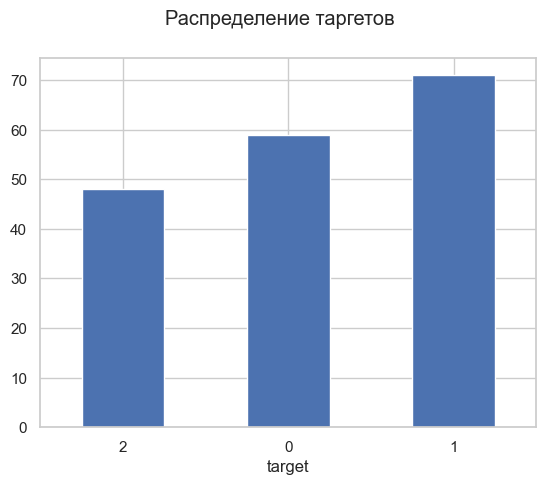

In [12]:
# твой код
df['target'].value_counts().sort_values().plot(kind='bar')
plt.suptitle('Распределение таргетов')
plt.xticks(rotation=0)
plt.show()

Класс `class_1` чуть впереди (40%), но разрыв с остальными умеренный. На multiclass с таким балансом общая accuracy остаётся честной метрикой.

### 1.3 Как выглядит один признак

Прежде чем смотреть все 13 признаков сразу, посмотрим на один — `alcohol`. Это самый интуитивный показатель.

Text(0.5, 0.98, 'распределение алкоголя')

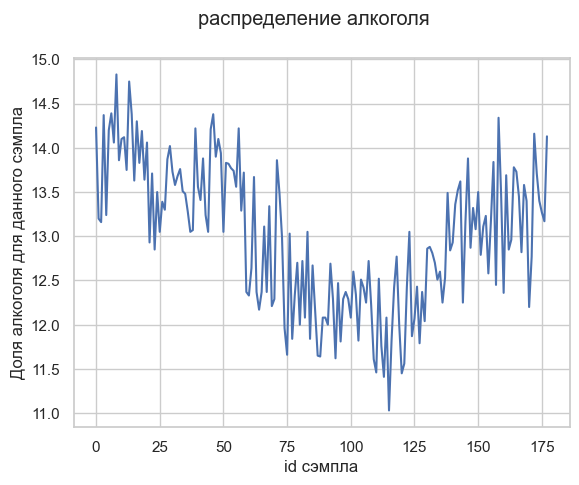

In [13]:
# твой код
df['alcohol'].plot()
plt.ylabel('Доля алкоголя для данного сэмпла')
plt.xlabel('id сэмпла')
plt.suptitle('распределение алкоголя')

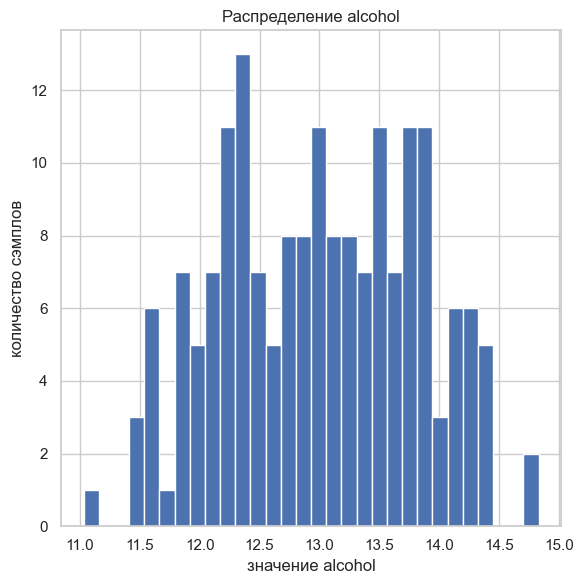

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.hist(x=df['alcohol'], bins=30)
ax.set_title('Распределение alcohol')
ax.set_ylabel('количество сэмплов')
ax.set_xlabel('значение alcohol')
plt.tight_layout()
plt.show()

Распределение **бимодальное**: видны два «горба». Это хорошо для классификации — два горба намекают, что разные классы группируются вокруг разных значений признака. Чтобы убедиться, посмотрим на распределение алкоголя **по классам**:

Text(0.5, 0.98, 'Распределение алкоголя по таргетам')

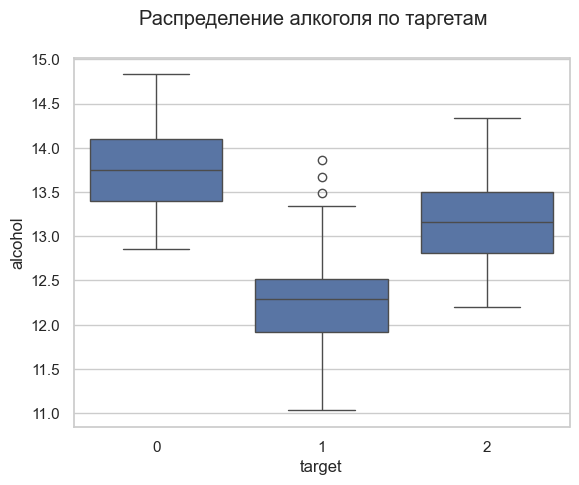

In [15]:
# твой код
sns.boxplot(data=df, x='target', y='alcohol')
plt.suptitle('Распределение алкоголя по таргетам')

In [16]:
y = df['target']

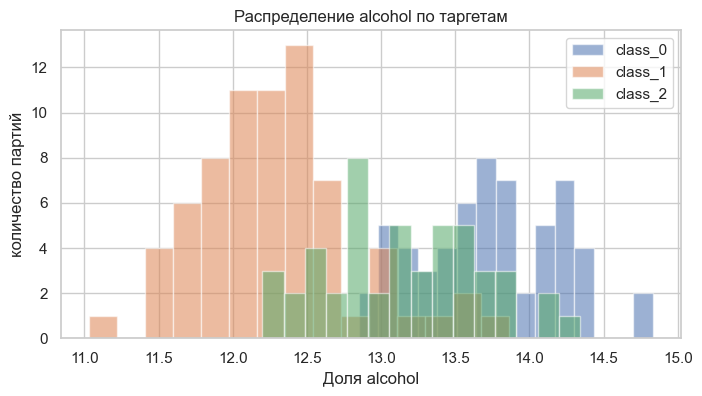

In [17]:
fig, ax = plt.subplots(figsize=(8, 4))
for cls_index, cls_name in enumerate(load_wine().target_names):
    ax.hist(df['alcohol'][y == cls_index], bins=15, alpha=0.55, label=cls_name)

ax.set_title('Распределение alcohol по таргетам')
ax.set_ylabel('количество партий')
ax.set_xlabel('Доля alcohol')
plt.legend()
plt.show()


Видно: `class_0` концентрируется на 13.5+, `class_1` около 12, `class_2` где-то посередине. Алкоголь — дискриминативный признак, дерево сможет построить по нему полезный сплит.

### 1.4 Все 13 признаков в сетке

Теперь посмотрим на все 13 признаков одним взглядом — каждый в своей маленькой ячейке. Сетка 4×4: 13 признаков займут 13 ячеек, 3 останутся пустыми.

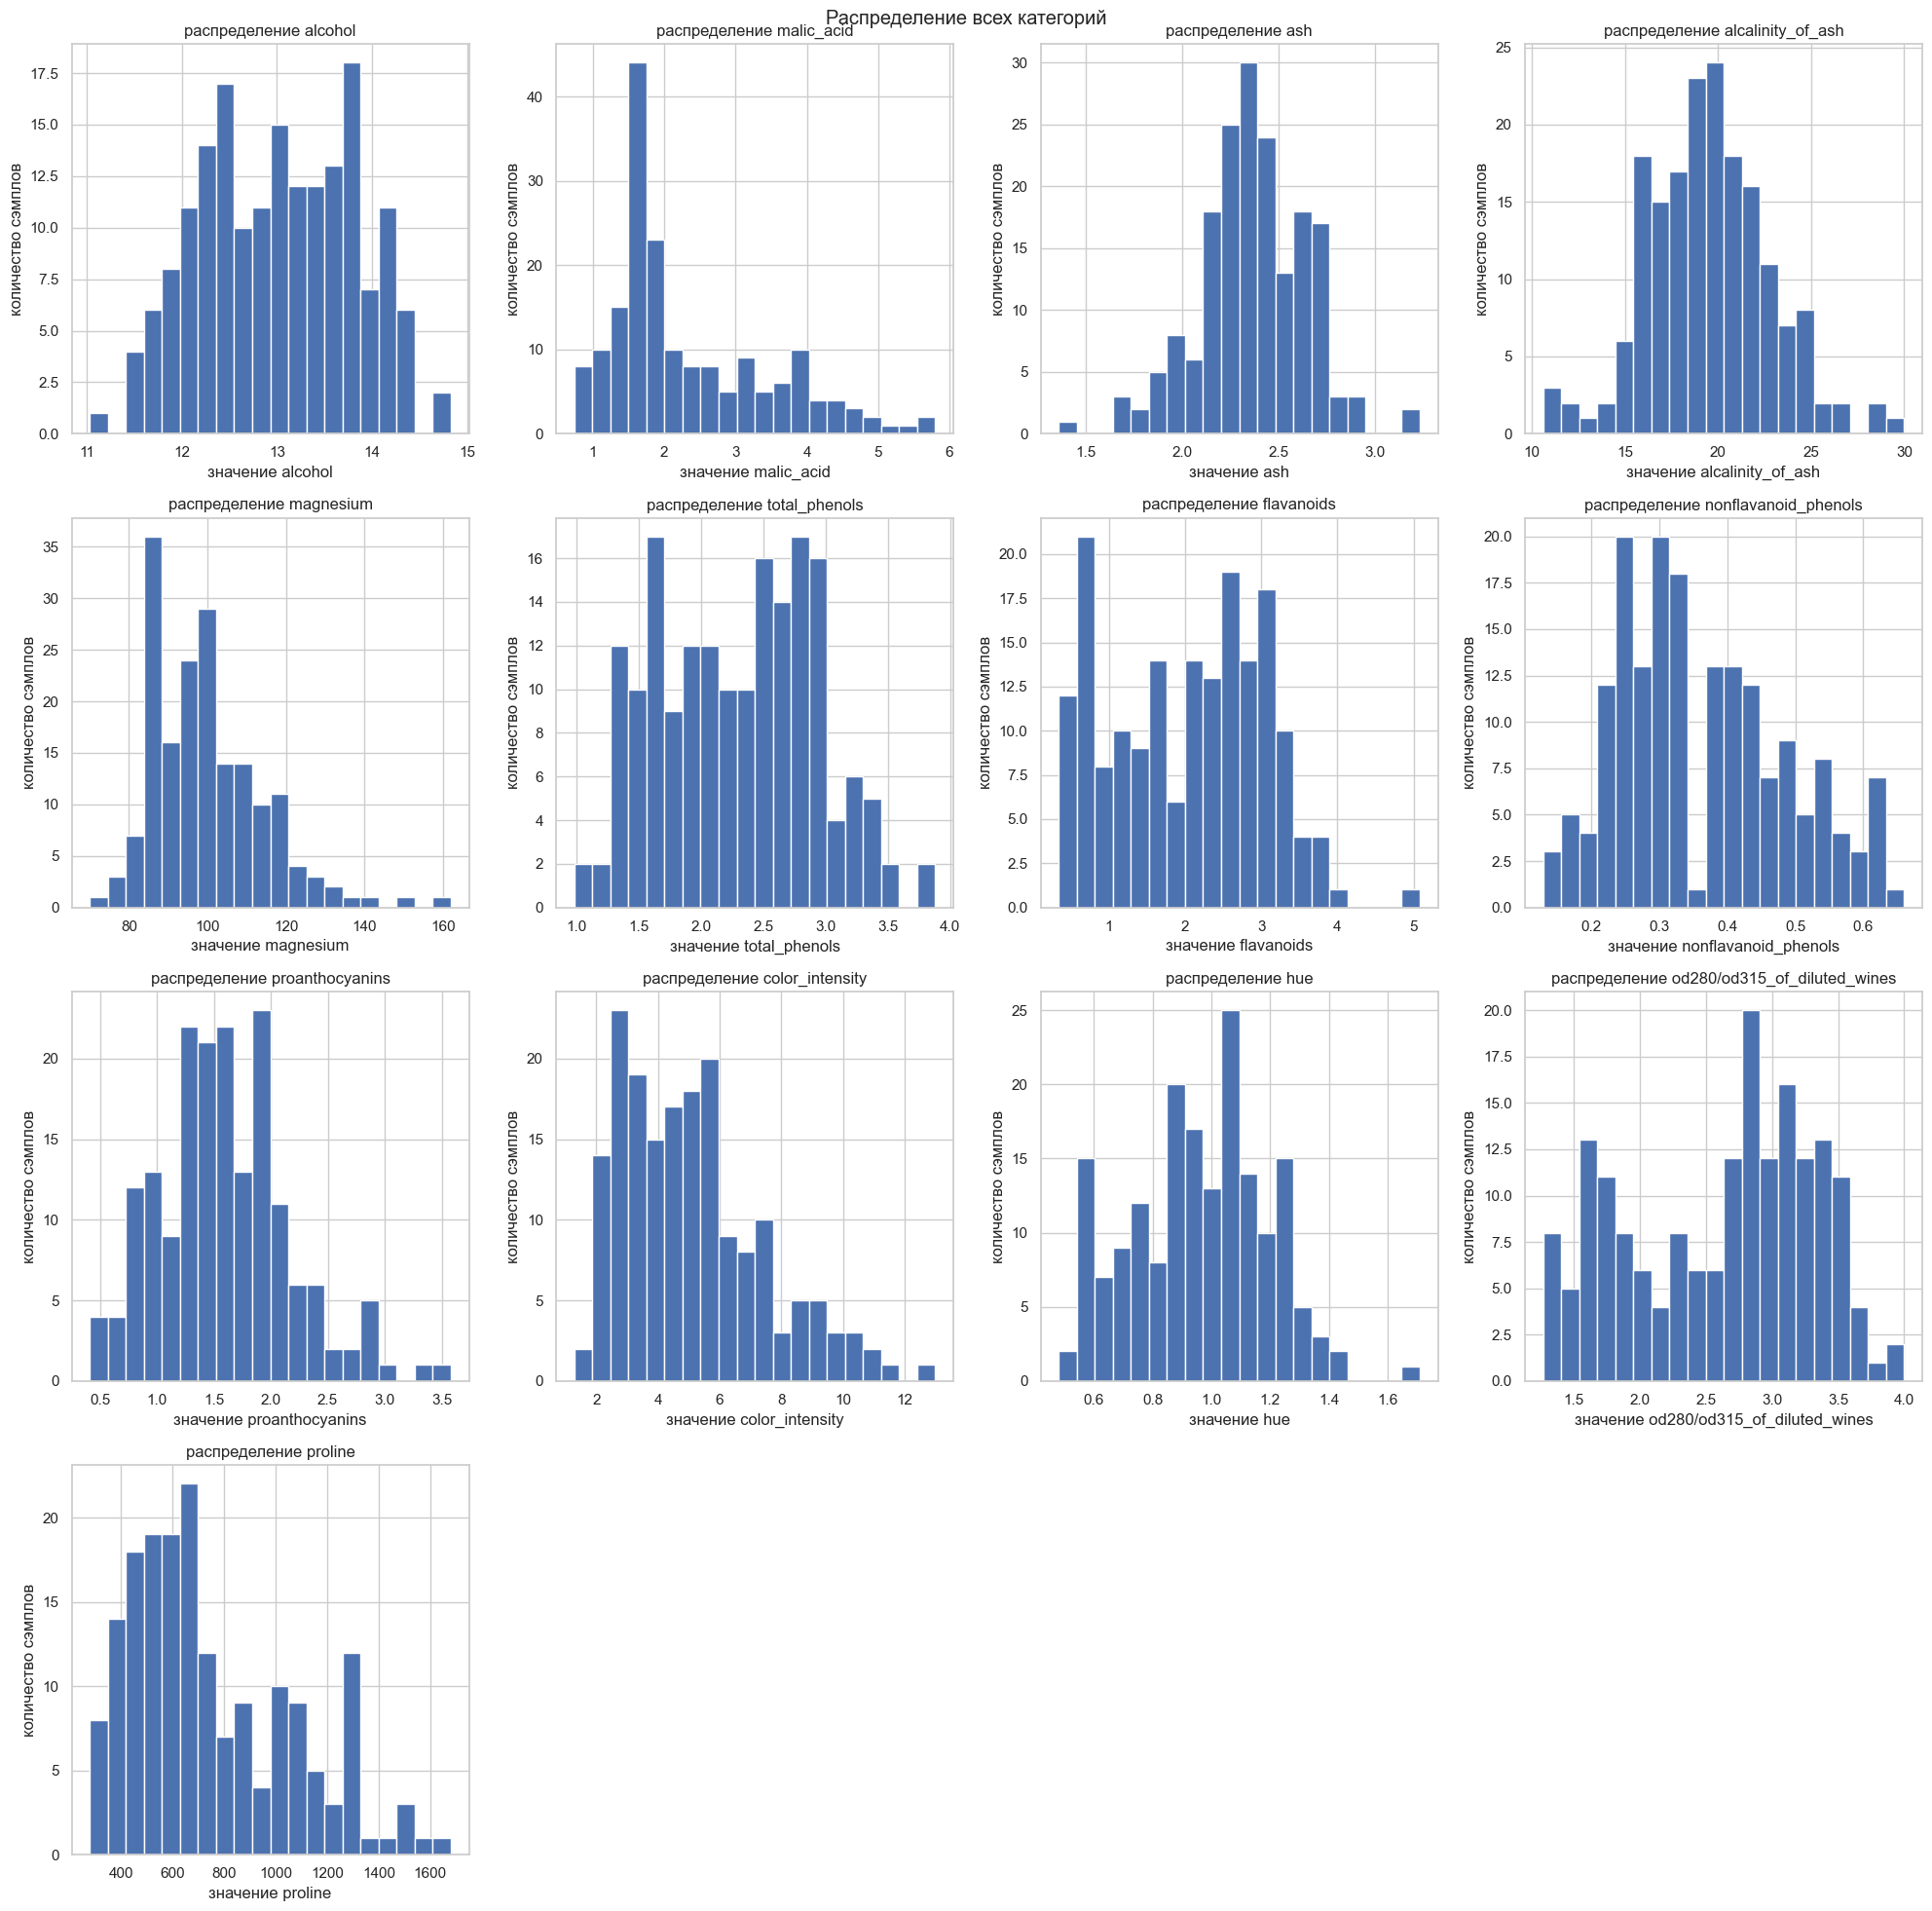

In [18]:
# твой код
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()
for i, feat in enumerate(df.columns.drop('target')):
    axes[i].hist(df[feat], bins=20)
    axes[i].set_xlabel(f'значение {feat}')
    axes[i].set_ylabel(f'количество сэмплов')
    axes[i].set_title(f'распределение {feat}')

for j in range(len(df.columns)-1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Распределение всех категорий')
plt.tight_layout()
plt.show()

Большинство распределений унимодальные (одна вершина), некоторые — `proline`, `magnesium` — со скосом вправо (длинный хвост в большие значения). Бимодальных, как у `alcohol`, чётко видных тут больше нет — классы будут различаться комбинациями признаков, а не одним резким разделителем.

### 1.5 Где классы реально различаются

Гистограмма всего датасета не отвечает на главный вопрос: **различаются ли классы по этому признаку**. Для этого есть boxplot по классам. Если коробки трёх классов расположены по-разному (по медиане), значит признак содержит сигнал. Если перекрываются — признак бесполезен.

Возьмём `flavanoids` — один из самых известных предикторов в Wine.

Text(0.5, 0.98, 'Распределение flavanoids по классам')

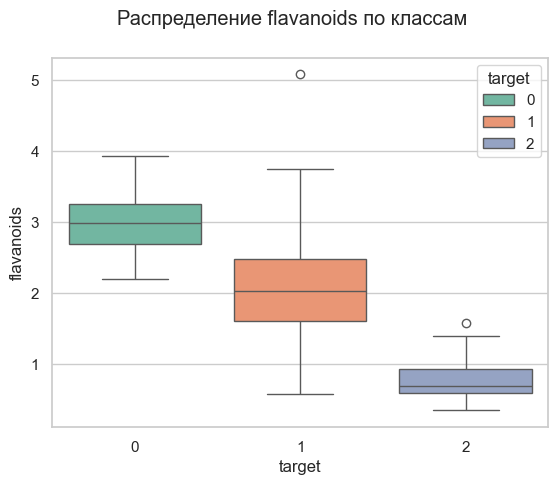

In [19]:
# твой код
sns.boxplot(data=df, x='target', y='flavanoids', palette='Set2', hue='target')
plt.suptitle('Распределение flavanoids по классам')

In [20]:
# твой код

Три коробки расположены **последовательно по медиане**: у `class_0` высокий уровень флавоноидов, у `class_1` средний, у `class_2` низкий. Перекрытий минимум. Это сильнейший разделитель — дерево скорее всего выберет именно этот признак для верхнего сплита.

### 1.6 Boxplot для топ-6 признаков

Соберём ту же картинку для шести самых важных признаков. По разделимости коробок будем понимать, кто из них вносит сигнал.

In [21]:
# твой код
top_features = [
    "alcohol",
    "flavanoids",
    "color_intensity",
    "proline",
    "od280/od315_of_diluted_wines",
    "hue",
]
df_box = df[top_features].copy()
df_box['target'] = df['target']

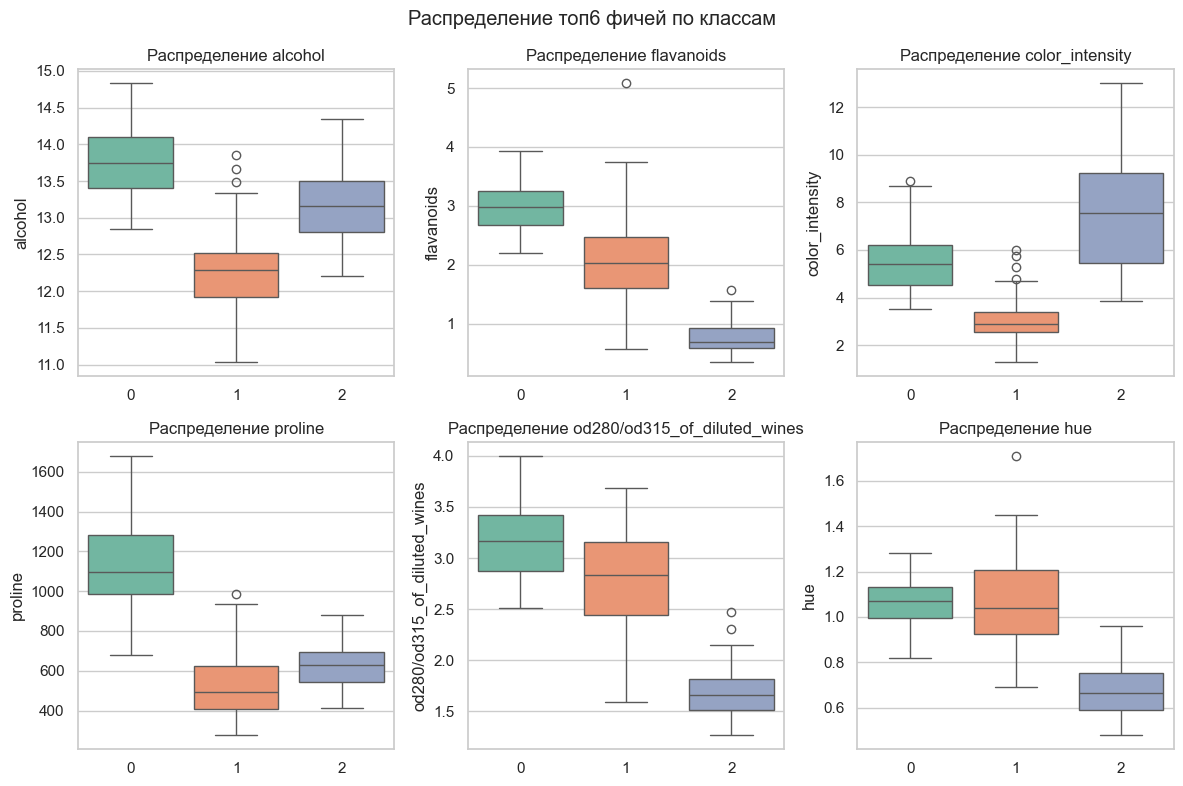

In [22]:
# твой код
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    sns.boxplot(data=df_box, x='target', y=feat, ax=axes[i], hue='target', palette='Set2', legend=False)
    axes[i].set_title(f'Распределение {feat}')
    axes[i].set_xlabel('')

plt.suptitle('Распределение топ6 фичей по классам')
plt.tight_layout()

**Что видим:**

- `flavanoids` и `od280/od315_of_diluted_wines` — почти идеальное разделение
- `proline` чётко выделяет `class_0` (высокий) от двух других
- `alcohol` отделяет `class_0` (выше) и `class_1` (ниже), но `class_2` пересекается с обоими
- `color_intensity` и `hue` менее дискриминативны, но всё ещё несут сигнал

Этих признаков достаточно для построения хорошего дерева.

### 1.7 Корреляции между признаками

Корреляционная матрица показывает, какие признаки несут одинаковую информацию. Высокая корреляция (> 0.8 по модулю) — значит одно из двух можно убрать. Для дерева это не критично (оно само выберет), но полезно понимать структуру.

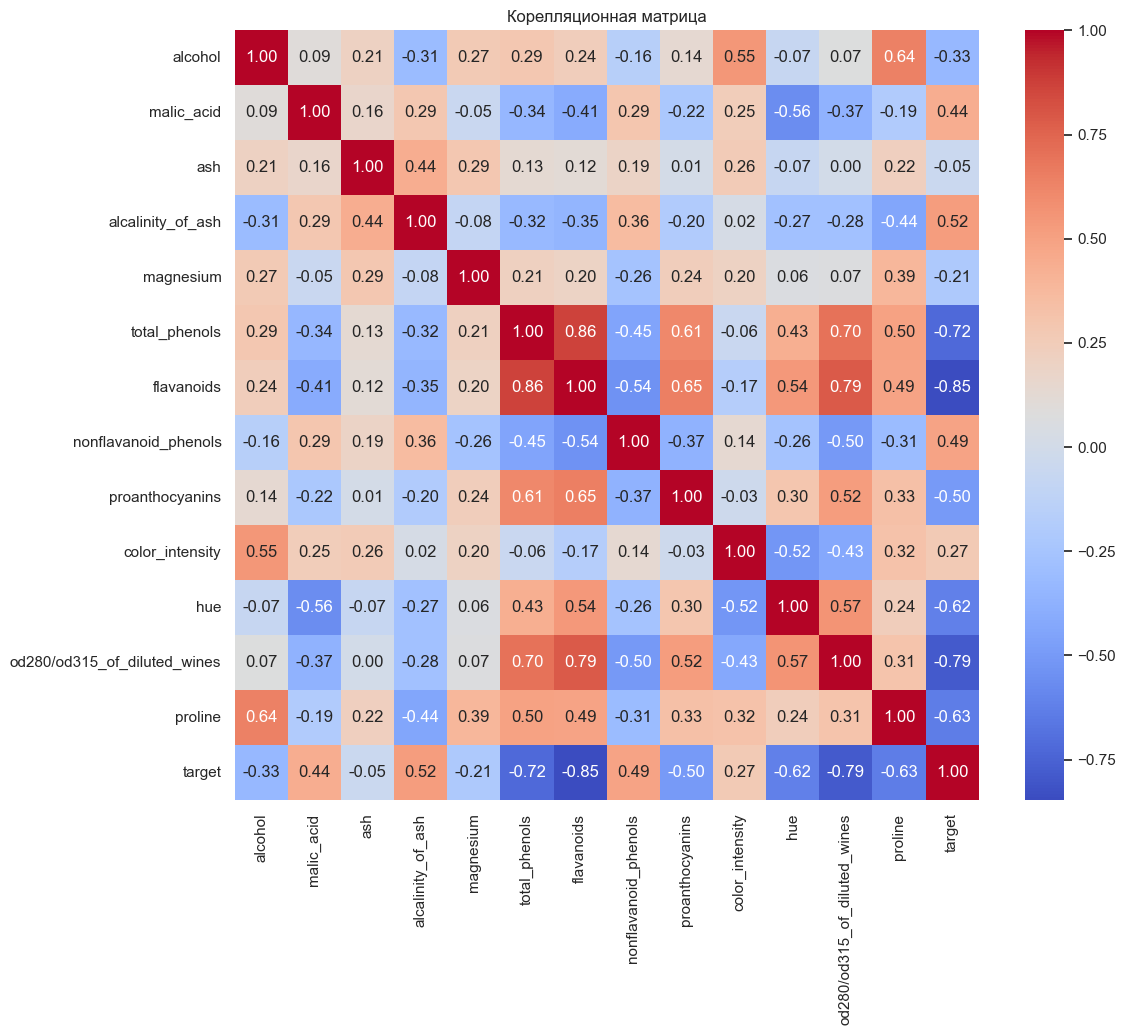

In [23]:
# твой код
fix, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
ax.set_title('Корелляционная матрица')
plt.show()

Это первые 5×5 значений. Чтобы увидеть всю матрицу — heatmap:

In [24]:
# твой код

**Главная пара с высокой корреляцией:** `flavanoids` ↔ `total_phenols` (≈ 0.86), `flavanoids` ↔ `od280/od315_of_diluted_wines` (≈ 0.79). Это химически осмысленно — флавоноиды это подкласс фенолов. Дерево возьмёт одну из коррелирующих фичей в сплит, остальное проигнорирует. Никаких действий с нашей стороны не нужно.

## Этап 2. Делим train/test и добавляем шум в разметку

Сначала чистый split 60/40 со `stratify=y`. Test трогаем **только в самом конце** — на нём измерим финальную метрику.

Потом в **обучающую** часть кладём label noise: переразметим 15% случайных строк на неправильный класс. Это симулирует реальную ситуацию — лаборант ошибается. Тестовую часть оставляем чистой (это аудит).

### 2.1 Чистый train/test split

In [25]:
# TODO: раздели X, y на train (60%) и test (40%).
# Используй train_test_split со stratify=y и random_state=SEED.
# Подсказка: X_train, X_test, y_train_clean, y_test = train_test_split(...)
# Решение: смотри wine_train_solution.ipynb если застрял
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train_clean, y_test = train_test_split(X, y, test_size=0.4, stratify=y)


In [26]:
# твой код

### 2.2 Добавляем label noise в train

15% строк train получат **неправильный** класс. Это симулирует ошибки лаборанта при разметке. Тест остаётся как есть.

In [27]:
# твой код
round(len(y_train_clean) * 0.15, 0)

16.0

Это число строк, которым переставим метку. Для каждой выбранной строки сдвигаем её класс на 1 или 2 (по модулю 3) — то есть присваиваем какой-то другой класс из трёх возможных:

In [28]:
# твой код
noised = y_train_clean.sample(16)

In [29]:
noised_1 = (noised + 1) % 3

In [30]:
print(noised_1)
print(noised)

137    0
152    0
8      1
153    0
59     2
26     1
27     1
31     1
5      1
49     1
0      1
161    0
88     2
3      1
12     1
115    2
Name: target, dtype: int64
137    2
152    2
8      0
153    2
59     1
26     0
27     0
31     0
5      0
49     0
0      0
161    2
88     1
3      0
12     0
115    1
Name: target, dtype: int64


In [31]:
idx = noised_1.keys

In [32]:
y_train = y_train_clean.copy()

In [33]:
noised_1.index

Index([137, 152, 8, 153, 59, 26, 27, 31, 5, 49, 0, 161, 88, 3, 12, 115], dtype='int64')

In [34]:
y_train.loc[noised_1.index] = noised_1

In [35]:
(y_train != y_train_clean).sum()

np.int64(16)

In [36]:
mask = (y_train != y_train_clean)
diff_indices = y_train[mask]
diff_indices

31     1
8      1
137    0
88     2
12     1
26     1
115    2
59     2
49     1
152    0
153    0
0      1
161    0
5      1
3      1
27     1
Name: target, dtype: int64

Сравним сколько меток отличается:

In [37]:
# твой код

Дальше используем `y_train_noisy` — это то, с чем работает модель. `y_train_clean` нам нужен только для отладки и сравнения. Test остаётся `y_test` — чистый аудит.

In [38]:
# твой код

## Этап 3. Базовая модель — учимся видеть переобучение

Сначала обучим дерево **без ограничений** (`max_depth=None`, `min_samples_leaf=1`) и посмотрим, что получится. Это полезный baseline по двум причинам:

1. Видим переобучение в чистом виде — train accuracy уйдёт в 1.0, test останется ниже
2. Получаем точку отсчёта для сравнения — все улучшения от регуляризации измеряются относительно этой модели

### 3.1 Обучаем дерево без регуляризации

In [39]:
# TODO: создай DecisionTreeClassifier без регуляризации (только random_state=SEED)
# и обучи на X_train, y_train (это уже шумная разметка).

clf_baseline = DecisionTreeClassifier(random_state=SEED)
clf_baseline.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

Дерево обучилось мгновенно (на сотне строк это секунды). Смотрим accuracy на train:

In [40]:
# TODO: посчитай accuracy на train. Используй accuracy_score(y_true, y_pred)
# и .predict() метод модели.

train_acc_base = accuracy_score(y_train, clf_baseline.predict(X_train))
train_acc_base


1.0

**Accuracy на train = 1.0** — модель идеально запомнила обучающую выборку, **включая её ошибки разметки**. Дерево без ограничений всегда может выучить train на 100%: оно просто наращивает сплиты, пока каждая точка не оказывается в собственном листе. Вместе с реальными зависимостями модель выучила и шум разметки — это и есть переобучение.

Теперь test (он чистый, без label noise):

In [41]:
# TODO: то же самое для test.

test_acc_base = accuracy_score(y_test, clf_baseline.predict(X_test))
test_acc_base


0.7777777777777778

In [42]:
# твой код

**Gap большой**. Между train (1.0) и test (~0.85) разрыв в 15% — это и есть переобучение в чистом виде. Дерево разрослось до состояния «по одному листу почти на каждое наблюдение train» и теряется на новых данных. На test, где разметка чистая, модель ошибается чаще — потому что она училась с погрешностями в train.

### 3.2 Насколько разрослось дерево

In [43]:
# твой код
print(f'Глубина: {clf_baseline.get_depth()}')

Глубина: 10


In [44]:
# твой код
print(f'Число листьев: {clf_baseline.get_n_leaves()}')

Число листьев: 20


In [45]:
print(f'Число делений: {clf_baseline.tree_.node_count}')

Число делений: 39


Дерево глубиной 6-9 уровней с 12-18 листьями — слишком сложное для сотни строк train. Каждый лист в среднем покрывает 5-9 наблюдений. Лекарство — **регуляризация**: ограничим, как глубоко может расти дерево и сколько примеров обязано быть в листе.

## Этап 4. Подбор регуляризации

У `DecisionTreeClassifier` есть два главных гиперпараметра, которые контролируют сложность дерева:

- **`max_depth`** — максимальная глубина дерева. Чем меньше, тем проще модель и тем хуже она запоминает шум
- **`min_samples_leaf`** — минимальное число наблюдений в листе. Чем больше, тем стабильнее модель: один выброс не создаст лист на самого себя

Подбор делаем в два захода: сначала валидационная кривая по `max_depth`, потом `GridSearchCV` по обоим параметрам сразу. Test трогать на этом этапе **запрещено** — он только для финальной независимой проверки.

### 4.1 Валидационная кривая по `max_depth`

Идея: для каждой глубины посчитать train accuracy (на трейне) и cross-val accuracy (среднее по 5 фолдам внутри трейна). Когда train сильно выше CV — переобучение. Когда они близки и CV максимальный — оптимум.

Сначала перебираем глубины и для каждой обучаем дерево на полном train, потом запускаем 5-fold CV. Делаем это в цикле.

In [46]:
# твой код
train_scores = []
cv_scores = []
cv_stds = []

for d in range(1, 8):
    model = DecisionTreeClassifier(random_state=SEED, max_depth=d)
    model.fit(X_train, y_train)
    score = accuracy_score(y_train, model.predict(X_train))
    model_cv = DecisionTreeClassifier(random_state=SEED, max_depth=d)
    CV_score = cross_val_score(model_cv, X_train, y_train, cv=5, scoring='accuracy')
    train_scores.append(score)
    cv_scores.append(CV_score.mean())
    cv_stds.append(CV_score.std())

Цикл по глубинам — для каждой считаем train accuracy и CV accuracy:

Получили три параллельных списка. Соберём их в DataFrame:

In [47]:
# твой код
depth_results = pd.DataFrame({
    'max_depth': [str(d) for d in range(1, 8)],
    'train_score': np.round(train_scores, 4),
    'cv_mean': np.round(cv_scores, 4),
    'cv_stds': np.round(cv_stds, 4)
})

In [48]:
depth_results

,max_depth,train_score,cv_mean,cv_stds
0,1,0.6415,0.5848,0.0354
1,2,0.8208,0.7177,0.0757
2,3,0.8679,0.6887,0.0216
3,4,0.9151,0.7078,0.0130
4,5,0.9434,0.6978,0.0498
5,6,0.9623,0.6883,0.0659
6,7,0.9717,0.6883,0.0659


**Что видно из таблицы:**

- При маленькой глубине (`max_depth=2`) train невысокий — дерево слишком простое
- При большой (`max_depth=10` или `None`) train близок к 1.0, CV выходит на плато
- CV максимальный где-то посередине — это и есть оптимум

Нагляднее на графике.

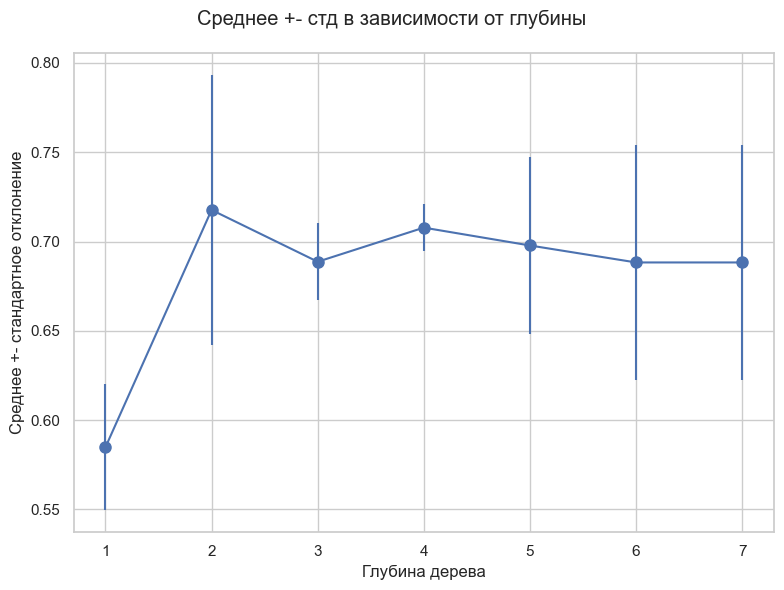

In [49]:
plt.figure(figsize=(8, 6))
plt.errorbar(x=depth_results['max_depth'], y=depth_results['cv_mean'], yerr=depth_results['cv_stds'],
             marker='o', linestyle='-', markersize=8)
plt.xlabel('Глубина дерева')
plt.ylabel('Среднее +- стандартное отклонение')
plt.suptitle('Среднее +- стд в зависимости от глубины')
plt.tight_layout()
plt.show()

### 4.2 Рисуем валидационную кривую

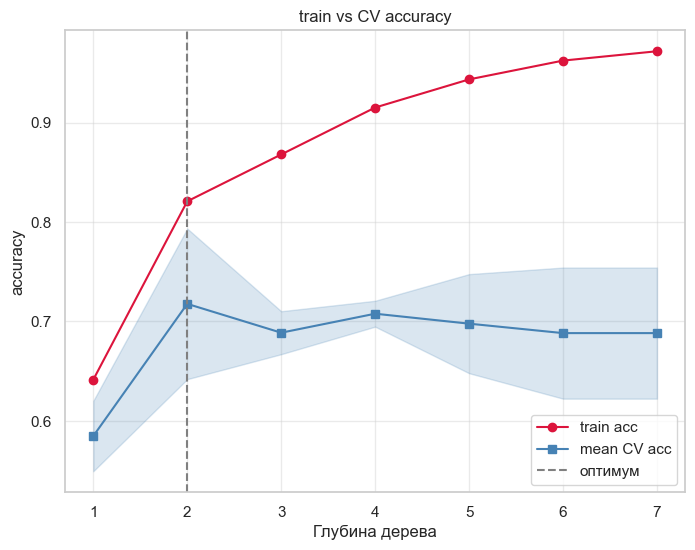

In [50]:
# твой код
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(depth_results['max_depth'], depth_results['train_score'], marker='o', color='crimson', label='train acc')
ax.plot(depth_results['max_depth'], depth_results['cv_mean'], marker='s', color='steelblue', label='mean CV acc')
ax.fill_between(depth_results['max_depth'],
                np.array(depth_results['cv_mean'] - depth_results['cv_stds']),
                np.array(depth_results['cv_mean'] + depth_results['cv_stds']),
                color='steelblue',alpha=0.2)
ax.set_xlabel('Глубина дерева')
ax.set_ylabel('accuracy')
ax.set_title('train vs CV accuracy')
ax.axvline(depth_results['cv_mean'].idxmax(), linestyle='--', color='gray', label='оптимум')
ax.grid(True, alpha=0.4)
plt.legend()
plt.show()

**Чтение графика:**

- Красная (train) растёт до 1.0 при глубине 5+ — модель запоминает train со всеми его погрешностями
- Синяя (CV) выходит на плато около depth 3-4 и дальше **не растёт**
- Между линиями растёт **gap** — это переобучение
- Заштрихованная синяя зона (± std) показывает, насколько стабильна CV-метрика

Оптимум — там, где CV максимальный и gap ещё небольшой.

### 4.3 GridSearchCV: тюним два параметра сразу

Валидационная кривая — для одного параметра. Если хотим тюнить `max_depth` и `min_samples_leaf` одновременно, нужен grid search: перебрать все комбинации и выбрать лучшую по CV-accuracy.

Сетку берём небольшую — 4 × 5 = 20 комбинаций × 5 фолдов = 100 fit'ов. Это пара секунд.

In [51]:
# TODO: задай param_grid для GridSearchCV.
# Параметры для перебора: max_depth (попробуй 2-5) и min_samples_leaf (попробуй 1-10).

param_grid = {
    "max_depth": [2, 3, 4, 5],
    "min_samples_leaf": [1, 2, 4, 6, 8, 10],
}


In [52]:
# TODO: создай GridSearchCV с estimator=DecisionTreeClassifier(random_state=SEED),
# param_grid (как выше), cv=5, scoring="accuracy", n_jobs=-1.
# Запусти grid.fit(X_train, y_train).

grid = GridSearchCV(DecisionTreeClassifier(random_state=SEED), param_grid=param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'max_depth': [2, 3, 4, 5],
                         'min_samples_leaf': [1, 2, 4, 6, 8, 10]},
             scoring='accuracy')

GridSearchCV сам перебрал комбинации и выбрал лучшую:

In [53]:
# твой код
grid.best_estimator_

DecisionTreeClassifier(max_depth=2, min_samples_leaf=8, random_state=42)

In [54]:
# твой код
f'best cv accuracy: {grid.best_score_}'

'best cv accuracy: 0.7268398268398268'

Посмотрим топ-5 комбинаций — какие ещё параметры были близки к лидеру:

In [55]:
# твой код
top_results = pd.DataFrame(grid.cv_results_)[
    ['param_max_depth', 'param_min_samples_leaf', 'mean_test_score', 'std_test_score']
].sort_values('mean_test_score', ascending=False).head()
top_results.round(4)

,param_max_depth,param_min_samples_leaf,mean_test_score,std_test_score
5,2,10,0.7268,0.0906
4,2,8,0.7268,0.0906
0,2,1,0.7177,0.0757
1,2,2,0.7177,0.0757
2,2,4,0.7177,0.0968


Лучшая комбинация — небольшое дерево с увеличенным `min_samples_leaf`. Этот же набор параметров используем дальше в финальной модели.

## Этап 5. Финальная модель + честная оценка на test

Обучаем дерево с лучшими гиперпараметрами на полном train (со всем шумом разметки!), затем измеряем accuracy на test (test трогаем здесь **впервые**).

In [56]:
# TODO: создай финальную модель с лучшими параметрами grid.best_params_
# (распакуй через **) и random_state=SEED. Обучи на X_train, y_train.

clf_final = DecisionTreeClassifier(random_state=SEED, **grid.best_params_)
clf_final.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=2, min_samples_leaf=8, random_state=42)

In [57]:
# TODO: train accuracy финальной модели.

train_acc_final = accuracy_score(y_train, clf_final.predict(X_train))
train_acc_final


0.7924528301886793

Train accuracy у финальной модели **ниже 1.0** — это сознательный отказ от запоминания каждой точки. Те 15% строк с шумной разметкой модель всё равно отнесёт к их «настоящему» классу, не пытаясь подгоняться.

In [58]:
# TODO: test accuracy финальной модели.

test_acc_final = accuracy_score(y_test, clf_final.predict(X_test))
test_acc_final


0.8194444444444444

In [59]:
# твой код
f'final_gap(train-test): {train_acc_final - test_acc_final:.2f}'

'final_gap(train-test): -0.03'

**Сравним с baseline:**

| Метрика | Baseline | Final |
|---|---|---|
| train accuracy | 1.0 | ниже 1.0 (модель не запоминает каждую точку) |
| test accuracy | ~0.85 | выше baseline (регуляризация защитила от шума разметки) |
| gap | ~0.15 | сильно меньше |

Регуляризация дала видимый эффект: test поднялся, gap сузился. На multiclass с label noise это и есть главное доказательство, что регуляризация работает.

### 5.1 Подробные метрики на test

In [60]:
# твой код
y_pred_final = clf_final.predict(X_test)
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.71      1.00      0.83        24
           1       0.92      0.76      0.83        29
           2       0.93      0.68      0.79        19

    accuracy                           0.82        72
   macro avg       0.85      0.81      0.82        72
weighted avg       0.85      0.82      0.82        72



Per-class precision/recall показывает, как модель работает на каждом классе отдельно. Для multiclass это критично — общая accuracy может скрывать, что один из классов модель путает чаще.

## Этап 5.2. Сравнение baseline vs final

Главное достижение регуляризации — сжать gap между train и test и устоять перед шумом разметки. На графиках ниже видно это конкретно.

### 5.2.1 Confusion matrix: baseline vs final

Confusion matrix показывает, на каких именно классах модель ошибается. Диагональ — правильные ответы, off-diagonal — ошибки.

In [61]:
# твой код
confusion_matrix(y_test, y_pred_final)

array([[24,  0,  0],
       [ 6, 22,  1],
       [ 4,  2, 13]])

In [62]:
# твой код

Эти же матрицы рядом, в графическом виде:

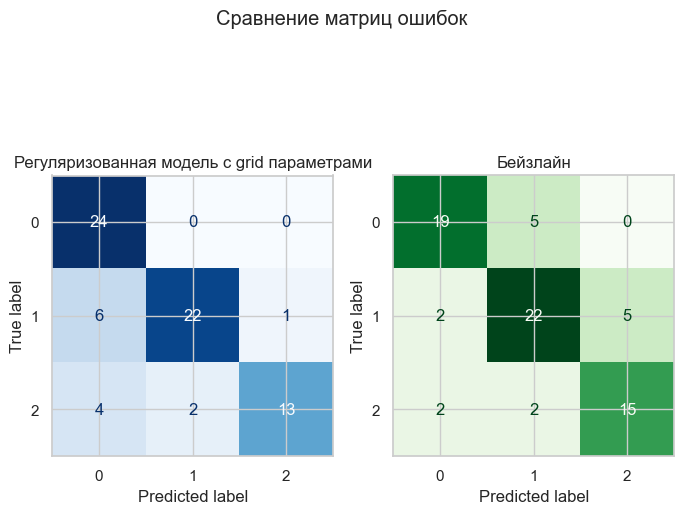

In [63]:
# твой код
fig, axes = plt.subplots(1, 2, figsize=(7, 6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_final)).plot(ax=axes[0],
                                                                    cmap='Blues', colorbar=False)
axes[0].set_title('Регуляризованная модель с grid параметрами')

ConfusionMatrixDisplay(confusion_matrix(y_test, clf_baseline.predict(X_test))).plot(ax=axes[1],
                                                                    cmap='Greens', colorbar=False)
axes[1].set_title('Бейзлайн')
plt.suptitle('Сравнение матриц ошибок')
plt.tight_layout()
plt.show()

В финальной матрице на диагонали больше чисел — больше правильных ответов. Off-diagonal — меньше. Регуляризация сохранила обобщающую способность даже на шумных тренировочных данных.

### 5.2.2 Общие метрики train/test для двух моделей

Соберём 4 главных числа (accuracy и macro-F1 на train и test) для baseline и final в одну таблицу. Так увидим, как закрылся gap.

In [64]:
# твой код
train_f1_base = f1_score(y_train, clf_baseline.predict(X_train), average="macro")
train_f1_final = f1_score(y_train, clf_final.predict(X_train), average="macro")
test_f1_base = f1_score(y_test, clf_baseline.predict(X_test), average="macro")
test_f1_final = f1_score(y_test, y_pred_final, average="macro")

In [65]:
# твой код
metrics = pd.DataFrame({
    'metric': ['accuracy_train', 'accuracy_test', 'macro_f1_train', 'macro_f1_test'],
    'baseline': [train_acc_base, test_acc_base, train_f1_base, test_f1_base],
    "final": [train_acc_final, test_acc_final, train_f1_final, test_f1_final],
})
metrics.round(3)


,metric,baseline,final
0,accuracy_train,1.000,0.792
1,accuracy_test,0.778,0.819
2,macro_f1_train,1.000,0.797
3,macro_f1_test,0.779,0.815


Эти же числа на bar chart:

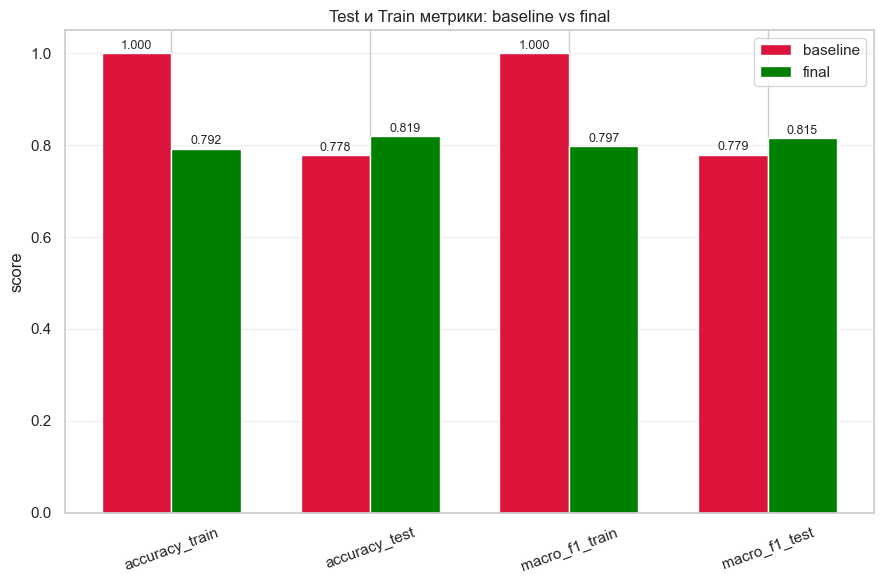

In [66]:
# твой код
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars_b = ax.bar(x - width/2, metrics['baseline'], width, label='baseline', color='crimson')
bars_f = ax.bar(x + width/2, metrics['final'], width, label='final', color='green')
ax.set_xticks(x)
ax.set_xticklabels(metrics['metric'], rotation=20)
ax.set_ylim(0, 1.05)
ax.set_ylabel('score')
ax.set_title('Test и Train метрики: baseline vs final')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

for bars in (bars_b, bars_f):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01, f'{height:.3f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

Train-метрики у baseline у самого верха (≈ 1.0), у final — пониже. Test-метрики у final **выше** baseline. Главное — сократился разрыв между train и test, модель стала **честнее**: она признаёт, что на 15% train разметка ошибочна, и не пытается их выучить.

### 5.2.3 Per-class F1

Какому именно классу регуляризация помогла? Считаем F1 отдельно для каждого из трёх классов.

In [67]:
y.unique()

array([0, 1, 2])

In [68]:
# твой код
f1_per_class_base = f1_score(y_test, clf_baseline.predict(X_test), average=None)
f1_per_class_final = f1_score(y_test, y_pred_final, average=None)

per_class = pd.DataFrame({
    "class": y.unique(),
    "baseline": np.round(f1_per_class_base, 3),
    "final": np.round(f1_per_class_final, 3),
})
per_class

,class,baseline,final
0,0,0.809,0.828
1,1,0.759,0.830
2,2,0.769,0.788


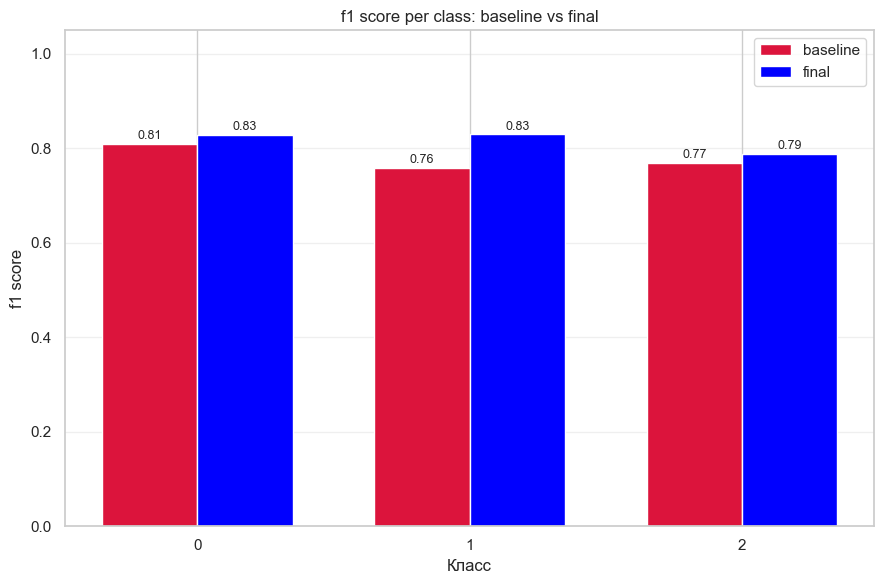

In [69]:
# твой код
x = np.arange(len(per_class))
width=0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width/2, per_class['baseline'], width, label='baseline', color='crimson')
ax.bar(x + width/2, per_class['final'], width, label='final', color='blue')

for i, (b, f) in enumerate(zip(per_class['baseline'], per_class['final'])):
    ax.text(i - width/2, b + 0.01, f'{b:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, f + 0.01, f'{f:.2f}', ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(per_class['class'])
ax.set_ylim(0, 1.05)
ax.set_xlabel('Класс')
ax.set_ylabel('f1 score')
ax.set_title('f1 score per class: baseline vs final')
plt.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


На multiclass общая accuracy может остаться той же, но один класс стал распознаваться сильно лучше за счёт другого. Per-class F1 это видит.

### 5.2.4 Сами деревья: side-by-side

Самый наглядный результат регуляризации — это сами деревья. Слева baseline без ограничений, справа final.

Baseline-дерево слева разрослось до десятков узлов, многие из них существуют ради нескольких ошибочно размеченных точек. Финальное справа — компактное, 4-6 решающих узлов: его можно нарисовать на доске и объяснить бизнесу. Регуляризация — это буквально «обрезание лишних веток», и теперь это видно глазом.

### 5.2.5 Feature importance

Какие признаки модель реально использует в решающих сплитах.

In [76]:
importances_final = pd.Series(clf_final.feature_importances_, index=X.columns)
importances_final.sort_values(ascending=False).head(10).round(4)

hue                     0.4862
alcohol                 0.4225
proanthocyanins         0.0913
malic_acid              0.0000
ash                     0.0000
magnesium               0.0000
alcalinity_of_ash       0.0000
flavanoids              0.0000
total_phenols           0.0000
nonflavanoid_phenols    0.0000
dtype: float64

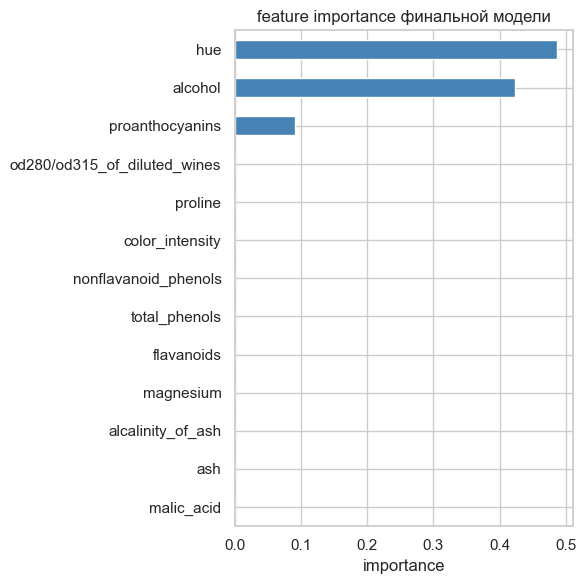

In [80]:
# твой код
top_n = importances_final.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(6, 6))
top_n.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('feature importance финальной модели')
ax.set_xlabel('importance')
plt.tight_layout()
plt.show()

В верху рейтинга — `flavanoids`, `proline`, `color_intensity`. Те самые признаки, у которых на boxplot были раздельные коробки по классам. Сигнал ровно там, где он и должен был быть.

## Этап 6. Сохраняем модель в pickle

`joblib.dump` сериализует обученный объект `DecisionTreeClassifier` в бинарный `.pkl`-файл. На этапе сервиса (Шаг 3 проекта) FastAPI грузит этот файл одним вызовом `joblib.load` — внутри получаем тот же объект с теми же параметрами, готовый отвечать на `predict_proba`.

**Важно:** версия sklearn при сохранении и при загрузке должна совпадать. Иначе можно получить deprecation warning или прямую ошибку. На Шаге 5 проекта мы зафиксируем `scikit-learn==1.6.1` в `requirements.txt`.

In [81]:
# TODO: сохрани финальную модель в MODEL_PATH через joblib.dump(model, path).
# Потом распечатай размер файла в КБ.

joblib.dump(clf_final, MODEL_PATH)

size_kb = MODEL_PATH.stat().st_size / 1024
print(f"Saved {MODEL_PATH} ({size_kb:.1f} KB)")


Saved \models\wine_model.pkl (2.3 KB)


### 6.1 Sanity check: загружаем pickle и предсказываем

Это та же операция, которую FastAPI будет делать при старте на Шаге 3 проекта. Если здесь работает — будет работать и в сервисе.

In [82]:
# твой код
loaded = joblib.load(MODEL_PATH)
type(loaded).__name__

'DecisionTreeClassifier'

In [83]:
# твой код
sample = X_test.iloc[[0]]
sample

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
39,14.22,3.99,2.51,13.2,128.0,3.0,3.04,0.2,2.08,5.1,0.89,3.53,760.0


In [94]:
list(y.unique().astype(int))[0]

np.int64(0)

In [95]:
# твой код
true_class = y_test.iloc[0]
predicted_class = loaded.predict(sample)
proba = loaded.predict_proba(sample)[0]

print(f'истинный класс:      {true_class}')
print(f'Предсказанный класс: {predicted_class}')
print(f'Вероятности: ')
for cls, p in zip(list(y.unique()), proba):
    print(f"  {cls}: {p:.3f}")

истинный класс:      0
Предсказанный класс: [0]
Вероятности: 
  0: 0.675
  1: 0.275
  2: 0.050


**Готово.** Файл `models/wine_model.pkl` лежит на диске и проходит sanity check — после загрузки он предсказывает правильный класс с понятными вероятностями. Этот же `joblib.load(...)` будет вызываться при старте FastAPI-сервиса.

## Что дальше

Возвращайся в `content.md` к **Шагу 2** — там начинается этап обёртки модели в сервис: Pydantic-схема для запроса, эндпоинт `/predict`, HTML-форма для браузера, тесты, CI/CD и проверка на публичном URL.

In [98]:
from pathlib import Path
import joblib

MODEL_PATH = Path("../models/wine_model.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

# Сохраняем модель
joblib.dump(clf_final, MODEL_PATH)

# Проверяем файл
if MODEL_PATH.exists():
    size_kb = MODEL_PATH.stat().st_size / 1024
    print(f"✓ Модель сохранена: {MODEL_PATH}")
    print(f"  Размер: {size_kb:.1f} KB")
    print(f"  Полный путь: {MODEL_PATH.absolute()}")
else:
    print(f"✗ Файл не найден по пути {MODEL_PATH}")

✓ Модель сохранена: ..\models\wine_model.pkl
  Размер: 2.3 KB
  Полный путь: c:\Users\gavri\OneDrive\Рабочий стол\mentoring\..\models\wine_model.pkl
